# HVSR analysis - Terraza 28

Session `CBUCF_titanSMA_1614_20230519_213500_02`: 24.303 minutes, 200 Hz, N/E/Z.
**Terraza 28 is the user-supplied site label**, not a location decoded from headers. Coordinates, orientation and calibration remain unverified.

A bounded sensitivity search varies windowing, time-domain screening, detrending, smoothing, horizontal combination and frequency-domain rejection. The peak search is expanded to 1-50 Hz with spectral coverage from 0.2-50 Hz so SESAME checks around the 11 Hz peak are not cut off. No tested peak reaches A0 = 2 or passes SESAME clarity. The primary result uses a non-overlapping profile: 30-second windows, bandwidth 40, squared-average horizontals; f0 is about 11.19 Hz and A0 about 1.41.

A separate broad-band check finds a low-frequency candidate near 0.26 Hz with A0 about 1.56, but it has fewer than 10 cycles per 30-second window and fails reliability/clarity. It is not accepted as a resonance. Overlapping windows are correlated and do not provide independent evidence.


In [1]:
from pathlib import Path
from dataclasses import asdict
import hashlib
import importlib
import importlib.metadata
import platform
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next((folder for folder in (WORKING_DIR, *WORKING_DIR.parents)
             if (folder / 'utils/hvsr_tools.py').is_file() and (folder / 'data').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Run from the repository root or main/01_processing.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv
from utils import plotting as hp
hp = importlib.reload(hp)
hv = importlib.reload(hv)

versions = {name: importlib.metadata.version(name) for name in ('hvsrpy', 'obspy', 'numpy', 'scipy', 'pandas', 'matplotlib')}
versions['python'] = platform.python_version()

## 1. Inputs
 

In [2]:
import json

SESSION_ID = 'CBUCF_titanSMA_1614_20230519_213500_02'
SITE_LABEL = 'Terraza 28'
manifest = json.loads((ROOT / 'data/accelerometer/2023-05-19/sessions.json').read_text())
matches = [item for item in manifest['sessions'] if item['session_id'] == SESSION_ID]
if len(matches) != 1:
    raise ValueError(f'Expected exactly one catalog session: {SESSION_ID}')
session = matches[0]
INPUT_FILES = [ROOT / path for path in session['input_files']]
STARTTIME = session['starttime']
ENDTIME = session['endtime']
SAVE_OUTPUTS = True
OUTPUT_DIR = ROOT / 'outputs/terraza_28'
SHOW_WINDOW_CURVES = True
FIGURE_STYLE = hp.PaperStyle(width_in=6.4, font_size=7.0, tick_size=6.0, legend_size=6.0, dpi=300)
FIGURE_FORMATS = ('pdf', 'svg', 'png')

record = hv.load_record(INPUT_FILES, starttime=STARTTIME, endtime=ENDTIME)
if abs(record.meta['duration_s'] - session['duration_s']) > record.vt.dt_in_seconds:
    raise ValueError('Loaded duration disagrees with the catalog interval.')
record.meta.update(session_id=SESSION_ID, site_label=SITE_LABEL,
                   site_label_source='user supplied; not verified from headers',
                   start_bogota=session['start_bogota'], end_bogota=session['end_bogota'])
print(f"{SITE_LABEL}: {record.meta['duration_s'] / 60:.6f} minutes; "
      f"{session['start_bogota']} to {session['end_bogota']}")
display(pd.Series(record.meta, name='Recording'))

Terraza 28: 24.302833 minutes; 2023-05-19T16:35:24.665000-05:00 to 2023-05-19T16:59:42.835000-05:00


file name(s)                   [/home/orincon/ciudad-perdida-hvsr/data/accele...
deployed degrees from north                                                  0.0
current degrees from north                                                   0.0
station                                                                    CBUCF
starttime                                            2023-05-19T21:35:24.665000Z
sampling_rate_hz                                                           200.0
duration_s                                                               1458.17
session_id                                CBUCF_titanSMA_1614_20230519_213500_02
site_label                                                            Terraza 28
site_label_source                       user supplied; not verified from headers
start_bogota                                    2023-05-19T16:35:24.665000-05:00
end_bogota                                      2023-05-19T16:59:42.835000-05:00
Name: Recording, dtype: obje

## 2. Selected processing configuration

30-second continuous windows without overlap; vector STA/LTA (2/30 seconds, 0.1-3.0), 2-second transient padding and crest-factor limit 20. Linear detrending, 5%-per-side taper, native bandwidth-40 Konno-Ohmachi smoothing and squared-average horizontals. The primary peak-search band is 1-40 Hz. An expanded check covers 1-50 Hz, with spectra from 0.2-50 Hz, to assess the full f0/4 to 4*f0 range. The sensitivity sweeps reuse this same recording and are not independent validation.


In [3]:
params = hv.HVSRParams(
    # 1. Window duration and placement
    window_length_s=30.0,
    overlap_pct=0.0,
    window_selection='continuous',

    # 2. Time-domain screening of raw recordings
    anti_trigger=True,
    sta_s=2.0,
    lta_s=30.0,
    sta_lta_min=0.1,
    sta_lta_max=3.0,
    sta_lta_method='vector',
    sta_lta_amplitude='abs',
    transient_padding_s=2.0,
    max_crest_factor=20.0,
    clip_threshold_pct=None,

    # 3. Waveform preprocessing and FFT
    filter_corners_hz=(None, None),
    filter_order=5,
    detrend='linear',
    orient_to_degrees_from_north=None,
    taper_pct_per_side=5.0,
    fft_zero_padding=False,

    # 4. Spectral smoothing and horizontal combination
    smoothing='konno_and_ohmachi',
    smoothing_bandwidth=40.0,
    horizontal_combination='squared_average',

    # 5. Frequency sampling and peak-search band
    fmin=1,
    fmax=40,
    n_frequencies=800,
    frequency_spacing='log',
    peak_range_hz=(1, 40),

    # 6. Optional rejection based on H/V curves
    frequency_domain_rejection=True,
    fdr_n=2.5,
)
OUTPUT_PREFIX = f'terraza_28_{SESSION_ID}_{params.window_length_s:g}s_{params.overlap_pct:g}pct_overlap_selected_fdr'
result = hv.run_hvsr(record, params)
display(pd.Series(result.summary(), name='Analysis summary'))
fourier_data = hv.component_fourier_data(record, result)
component_spectra = fourier_data.smoothed

PEAK_THRESHOLD_A0 = 2.0
peak_sweep = hv.parameter_sweep(
    record, params,
    {
        'window_length_s': (15.0, 20.0, 30.0, 40.0),
        'overlap_pct': (0.0, 50.0),
        'smoothing_bandwidth': (20.0, 40.0),
        'horizontal_combination': ('geometric_mean', 'squared_average'),
    },
    time_blocks=4,
)
peak_sweep_success = peak_sweep.loc[peak_sweep['error'].isna()].copy() if 'error' in peak_sweep else peak_sweep.copy()
if peak_sweep_success.empty:
    raise RuntimeError('All profiles in the peak sensitivity sweep failed.')
best_sweep_peak = peak_sweep_success.loc[peak_sweep_success['A0_mean_curve'].idxmax()]
best_nonoverlap_peak = peak_sweep_success.loc[
    peak_sweep_success['overlap_pct'].eq(0)
].sort_values('A0_mean_curve', ascending=False).iloc[0]
broad_band_params = params.update(fmin=0.2, peak_range_hz=(0.2, params.fmax))
broad_band_result = hv.run_hvsr(record, broad_band_params, verbose=False)
broad_band_quality = hv.assess_sesame_quality(broad_band_result, time_blocks=None)['metrics']
robustness_params = params.update(fmin=0.2, fmax=50.0, n_frequencies=900, peak_range_hz=(1.0, 50.0))
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    robustness_sweep = hv.parameter_sweep(
        record, robustness_params,
        {
            'window_length_s': (15.0, 20.0, 30.0, 40.0),
            'anti_trigger': (False, True),
            'max_crest_factor': (None, 15.0, 20.0),
            'detrend': ('constant', 'linear'),
            'smoothing_bandwidth': (20.0, 40.0),
            'horizontal_combination': ('geometric_mean', 'squared_average'),
            'frequency_domain_rejection': (False, True),
        },
        time_blocks=4,
    )
robustness_success = robustness_sweep.loc[
    robustness_sweep['error'].isna()
].copy() if 'error' in robustness_sweep else robustness_sweep.copy()
robustness_success['defensible_candidate'] = (
    robustness_success['reliability_count'].eq(3)
    & robustness_success['clarity_count'].ge(5)
    & robustness_success['frequency_coverage_complete']
    & robustness_success['time_blocks_complete']
    & robustness_success['block_tracked_max_deviation_pct'].le(10)
)
if robustness_success.empty:
    raise RuntimeError('All profiles in the expanded robustness sweep failed.')
best_robustness_profile = robustness_success.sort_values(
    ['clarity_count', 'block_tracked_max_deviation_pct', 'A0_mean_curve'],
    ascending=[False, True, False],
).iloc[0]
peak_diagnostics = {
    'target_A0': PEAK_THRESHOLD_A0,
    'profiles_tested': int(len(peak_sweep_success)),
    'profiles_at_or_above_target': int((peak_sweep_success['A0_mean_curve'] >= PEAK_THRESHOLD_A0).sum()),
    'expanded_robustness_profiles': int(len(robustness_success)),
    'expanded_profiles_at_or_above_target': int((robustness_success['A0_mean_curve'] >= PEAK_THRESHOLD_A0).sum()),
    'expanded_defensible_candidates': int(robustness_success['defensible_candidate'].sum()),
    'best_expanded_quality_profile': {
        'window_length_s': float(best_robustness_profile['window_length_s']),
        'anti_trigger': bool(best_robustness_profile['anti_trigger']),
        'max_crest_factor': None if pd.isna(best_robustness_profile['max_crest_factor']) else float(best_robustness_profile['max_crest_factor']),
        'detrend': best_robustness_profile['detrend'],
        'smoothing_bandwidth': float(best_robustness_profile['smoothing_bandwidth']),
        'horizontal_combination': best_robustness_profile['horizontal_combination'],
        'frequency_domain_rejection': bool(best_robustness_profile['frequency_domain_rejection']),
        'f0_hz': float(best_robustness_profile['f0_mean_curve_hz']),
        'A0': float(best_robustness_profile['A0_mean_curve']),
        'reliability_count': int(best_robustness_profile['reliability_count']),
        'clarity_count': int(best_robustness_profile['clarity_count']),
        'block_tracked_max_deviation_pct': float(best_robustness_profile['block_tracked_max_deviation_pct']),
    },
    'best_tested_profile': {
        'window_length_s': float(best_sweep_peak['window_length_s']),
        'overlap_pct': float(best_sweep_peak['overlap_pct']),
        'smoothing_bandwidth': float(best_sweep_peak['smoothing_bandwidth']),
        'horizontal_combination': best_sweep_peak['horizontal_combination'],
        'f0_hz': float(best_sweep_peak['f0_mean_curve_hz']),
        'A0': float(best_sweep_peak['A0_mean_curve']),
    },
    'best_nonoverlap_profile': {
        'window_length_s': float(best_nonoverlap_peak['window_length_s']),
        'smoothing_bandwidth': float(best_nonoverlap_peak['smoothing_bandwidth']),
        'horizontal_combination': best_nonoverlap_peak['horizontal_combination'],
        'f0_hz': float(best_nonoverlap_peak['f0_mean_curve_hz']),
        'A0': float(best_nonoverlap_peak['A0_mean_curve']),
    },
    'broad_band_check': {
        'f0_hz': float(broad_band_result.peak[0]),
        'A0': float(broad_band_result.peak[1]),
        'cycles_per_window': float(broad_band_result.peak[0] * broad_band_params.window_length_s),
        'reliability_count': int(broad_band_quality['reliability_count']),
        'clarity_count': int(broad_band_quality['clarity_count']),
    },
}
display(pd.Series(peak_diagnostics, name='Peak search diagnostics'))

26/48 windows | f0=11.18556 Hz | A0=1.40788


n_grid_windows               48.000000
n_windows_time_selection     26.000000
n_candidates_before_crest    40.000000
n_crest_rejected             14.000000
n_windows                    26.000000
retained_fraction             0.541667
f0_mean_curve_hz             11.185555
A0_mean_curve                 1.407878
f0_windows_hz                 4.419038
f0_windows_low_hz             1.515081
f0_windows_high_hz           12.889007
f0_windows_std_hz             5.383196
A0_windows                    1.779091
fdr_iterations                1.000000
runtime_s                     0.177000
Name: Analysis summary, dtype: float64

target_A0                                                                             2.0
profiles_tested                                                                        32
profiles_at_or_above_target                                                             0
expanded_robustness_profiles                                                          384
expanded_profiles_at_or_above_target                                                    0
expanded_defensible_candidates                                                          0
best_expanded_quality_profile           {'window_length_s': 20.0, 'anti_trigger': True...
best_tested_profile                     {'window_length_s': 30.0, 'overlap_pct': 50.0,...
best_nonoverlap_profile                 {'window_length_s': 30.0, 'smoothing_bandwidth...
broad_band_check                        {'f0_hz': 0.2642319102730223, 'A0': 1.55836468...
Name: Peak search diagnostics, dtype: object

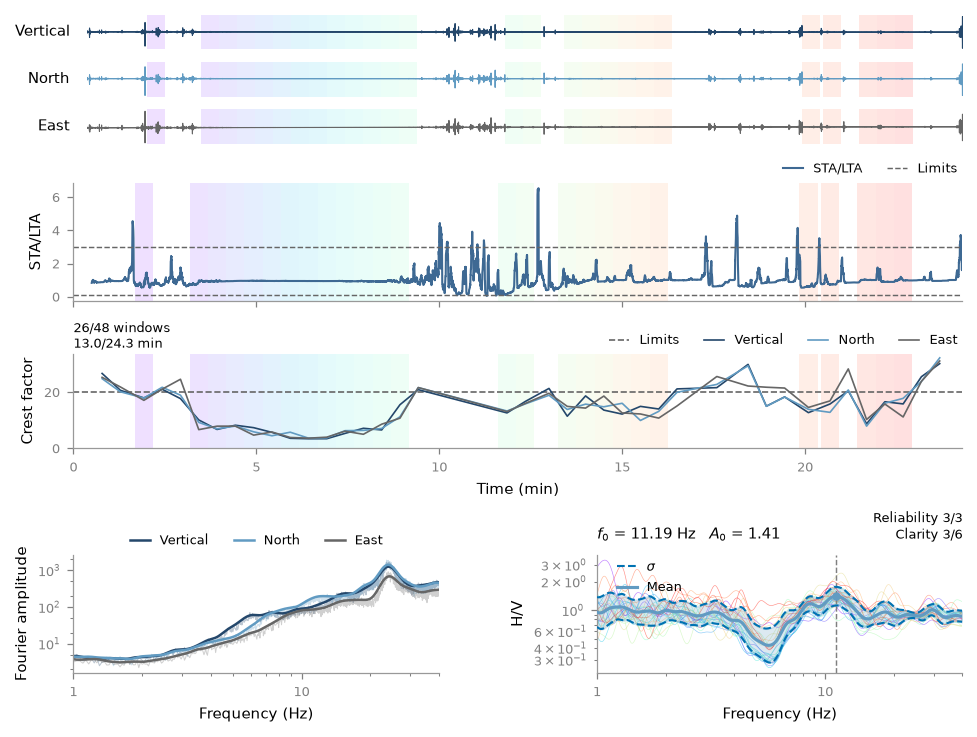

In [4]:
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

FIGURE_CONTROLS = {
    'height_in': 4.8,
    'show_raw_signals': True,
    'raw_height_ratio': 1.2,
    'height_ratios': (1.0, 1.0),
    'crest_height_ratio': 0.8,
    'crest_component_alpha': 1.0,
    'component_colors': {'Z': '#24476B', 'N': '#619BC2', 'E': '#666666'},
    'component_linestyles': {'Z': '-', 'N': '-', 'E': '-'},
    'line_width': 0.8,
    'fourier_line_width': 1.2,
    'fourier_grid': False,
    'window_cmap': 'rainbow',
    'accepted_alpha': 0.12,
    'sta_lta_ylim': None,
    'sta_lta_components': ('E',),
    'sta_lta_vector_color': '#3e6993ff',
    'sta_lta_line_width': 1.0,
    'sta_lta_alpha': 1.0,
    'fourier_yscale': 'log',
    'show_unsmoothed_fourier': True,
    'unsmoothed_fourier_alpha': 0.3,
    'unsmoothed_fourier_line_width': 0.5,
    'hvsr_yscale': None,
    'hvsr_window_alpha': 0.5,
    'hvsr_title_font_size': 7.0,
    'grid': False,
    'hspace': 0.04,  # Vertical spacing between rows
    'wspace': 0.15,  # Horizontal spacing between columns
}

def make_analysis_figure(record, result, component_spectra, controls, style, show_windows=False,
                         fourier_data=None):
    if controls['show_unsmoothed_fourier'] and fourier_data is None:
        raise ValueError('Rerun the processing cell to calculate unsmoothed Fourier amplitudes.')
    labels = {'Z': 'Vertical', 'N': 'North', 'E': 'East'}
    attributes = {'Z': 'vt', 'N': 'ns', 'E': 'ew'}
    if not controls['sta_lta_components'] or not set(controls['sta_lta_components']) <= set(labels):
        raise ValueError('sta_lta_components must contain N, E and/or Z.')
    dt = record.vt.dt_in_seconds
    time = np.arange(record.vt.n_samples) * dt / 60
    with hp.paper_context(style):
        figure = plt.figure(figsize=(style.width_in, controls['height_in']), layout='constrained')
        figure.get_layout_engine().set(
            hspace=controls['hspace'],
            wspace=controls['wspace'],
        )
        show_crest = result.params.max_crest_factor is not None
        ratios = list(controls['height_ratios'])
        if show_crest:
            ratios.insert(1, controls['crest_height_ratio'])
        raw_offset = int(controls['show_raw_signals'])
        if raw_offset:
            ratios.insert(0, controls['raw_height_ratio'])
        grid = figure.add_gridspec(len(ratios), 2, height_ratios=ratios)
        sta_lta_ax = figure.add_subplot(grid[raw_offset, :])
        crest_ax = figure.add_subplot(grid[raw_offset + 1, :], sharex=sta_lta_ax) if show_crest else None
        fourier_ax = figure.add_subplot(grid[-1, 0])
        hvsr_ax = figure.add_subplot(grid[-1, 1], sharex=fourier_ax)
        raw_axes = []
        if raw_offset:
            raw_grid = grid[0, :].subgridspec(3, 1, hspace=0.02)
            for index, (component, attribute) in enumerate(attributes.items()):
                axis = figure.add_subplot(raw_grid[index, 0], sharex=sta_lta_ax)
                signal = getattr(record, attribute)
                times, lower, upper = hp.waveform_envelope(signal.amplitude, dt)
                axis.fill_between(times, lower, upper, color=controls['component_colors'][component],
                                  edgecolor=controls['component_colors'][component],
                                  linewidth=0.5, rasterized=True, zorder=1)
                axis.set_ylabel(labels[component], rotation=0, ha='right', va='center',
                                labelpad=8, fontweight='normal')
                hp.style_axes(axis, style=style)
                axis.set_yticks([])
                axis.spines['left'].set_visible(False)
                axis.spines['bottom'].set_visible(False)
                axis.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
                raw_axes.append(axis)

        starts = result.window_starts_s[result.valid_mask] / 60
        ranks = np.argsort(np.argsort(starts))
        window_colors = plt.get_cmap(controls['window_cmap'])(ranks / max(len(starts) - 1, 1))
        length = result.params.window_length_s / 60
        polygons = [[(start, 0), (start + length, 0), (start + length, 1), (start, 1)]
                    for start in starts]
        time_axes = raw_axes + [sta_lta_ax] + ([crest_ax] if show_crest else [])
        for time_axis in time_axes:
            time_axis.add_collection(PolyCollection(
                polygons, transform=time_axis.get_xaxis_transform(),
                facecolors=window_colors, alpha=controls['accepted_alpha'],
                edgecolors='none', zorder=0))
        if show_crest:
            hp.plot_crest_factor(result, ax=crest_ax, style=style,
                                 show_decisions=False,
                                 component_alpha=controls['crest_component_alpha'],
                                 component_colors=controls['component_colors'])
            crest_ax.set_title('')
            crest_ax.legend(loc='lower right', bbox_to_anchor=(1, 1.02),
                            ncols=4, borderaxespad=0, fontsize=style.legend_size)
            sta_lta_ax.tick_params(labelbottom=False)
        displayed = ('R',) if result.params.sta_lta_method == 'vector' else controls['sta_lta_components']
        for component in displayed:
            label = 'STA/LTA' if component == 'R' else labels[component]
            ratio = result.diagnostics['sta_lta'].get(component)
            if ratio is None:
                if component == 'R':
                    ratio = hv.vector_sta_lta_ratio(record, result.params.sta_s, result.params.lta_s,
                                                   result.params.sta_lta_amplitude)
                else:
                    ratio = hv.sta_lta_ratio(getattr(record, attributes[component]).amplitude, dt,
                                            result.params.sta_s, result.params.lta_s,
                                            result.params.sta_lta_amplitude)
            finite = np.flatnonzero(np.isfinite(ratio))
            if not finite.size:
                warnings.warn(f'{label} STA/LTA has no finite values.', RuntimeWarning)
                continue
            color = controls['sta_lta_vector_color'] if component == 'R' else controls['component_colors'][component]
            sta_lta_ax.plot(time, ratio, color=color,
                            linestyle='-' if component == 'R' else controls['component_linestyles'][component],
                            lw=controls['sta_lta_line_width'], alpha=controls['sta_lta_alpha'],
                            label=label, rasterized=True)
        if result.params.anti_trigger:
            for index, limit in enumerate((result.params.sta_lta_min, result.params.sta_lta_max)):
                sta_lta_ax.axhline(limit, color='0.4', ls='--', lw=0.7,
                                  label='Limits' if index == 0 else None)
        sta_lta_ax.set(xlim=(0, (record.vt.n_samples - 1) * dt / 60),
                       xlabel='Time (min)', ylabel='STA/LTA')
        if show_crest:
            sta_lta_ax.set_xlabel('')
        if controls['sta_lta_ylim'] is not None:
            sta_lta_ax.set_ylim(controls['sta_lta_ylim'])
        handles, legend_labels = sta_lta_ax.get_legend_handles_labels()
        sta_lta_ax.legend(handles, legend_labels, ncols=3, loc='lower right',
                          bbox_to_anchor=(1, 1.02), borderaxespad=0)
        included_min = hv.accepted_signal_coverage(result)['unique_duration_min']
        total_min = (record.vt.n_samples - 1) * dt / 60
        selection_annotation = (
            f'{result.n_windows}/{result.n_grid_windows} windows\n'
            f'{included_min:.1f}/{total_min:.1f} min')
        annotation_ax = crest_ax if show_crest else sta_lta_ax
        annotation_ax.text(0, 1.02, selection_annotation, transform=annotation_ax.transAxes,
                        ha='left', va='bottom', fontsize=style.legend_size)

        for component, label in labels.items():
            if controls['show_unsmoothed_fourier']:
                visible = ((fourier_data.raw_frequency >= result.params.fmin)
                           & (fourier_data.raw_frequency <= result.params.fmax))
                raw = fourier_data.raw[component][:, visible]
                log_raw = np.full_like(raw, -np.inf)
                np.log(raw, out=log_raw, where=raw > 0)
                raw_mean = np.exp(log_raw.mean(axis=0))
                fourier_ax.plot(fourier_data.raw_frequency[visible], raw_mean,
                                color=controls['component_colors'][component],
                                alpha=controls['unsmoothed_fourier_alpha'],
                                lw=controls['unsmoothed_fourier_line_width'], zorder=1,
                                label='_nolegend_', rasterized=True)
            mean = np.exp(np.log(component_spectra[component]).mean(axis=0))
            fourier_ax.plot(result.frequency, mean, label=label,
                            color=controls['component_colors'][component],
                            linestyle=controls['component_linestyles'][component],
                            lw=controls['fourier_line_width'], zorder=2)
        fourier_ax.set(xscale='log', yscale=controls['fourier_yscale'],
                       xlim=(result.params.fmin, result.params.fmax), xlabel='Frequency (Hz)',
                       ylabel='Fourier amplitude')
        fourier_ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
        fourier_ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
                          ncols=3, borderaxespad=0)
        hp.plot_hvsr(result, show_windows=show_windows, title='', ax=hvsr_ax,
                     yscale=controls['hvsr_yscale'],
                     window_alpha=controls['hvsr_window_alpha'],
                     window_cmap=controls['window_cmap'], style=style)
        peak_annotation = hvsr_ax.texts[0]
        peak_title = peak_annotation.get_text().replace('\n', '   ')
        peak_annotation.remove()
        hvsr_ax.set_title(peak_title, loc='center', y=1.1, pad=0,
                          fontweight='normal', math_fontfamily='dejavusans')
        hvsr_ax.title.set_x(0)
        hvsr_ax.title.set_horizontalalignment('left')
        hvsr_ax.title.set_verticalalignment('bottom')
        legend_handles, legend_labels = hvsr_ax.get_legend_handles_labels()
        legend_order = [legend_labels.index(label) for label in (r'$\sigma$', 'Mean')
                        if label in legend_labels]
        hvsr_ax.legend([legend_handles[index] for index in legend_order],
                       [legend_labels[index] for index in legend_order],
                       loc='upper left', bbox_to_anchor=(0.04, 1),
                       ncols=1, borderaxespad=0, fontsize=style.legend_size, frameon=False)
        sesame_metrics = hv.assess_sesame_quality(result, time_blocks=None)['metrics']
        sesame_label = (
            f"Reliability {sesame_metrics['reliability_count']}/3\n"
            f"Clarity {sesame_metrics['clarity_count']}/6")
        hvsr_ax.text(1, 1.1, sesame_label, transform=hvsr_ax.transAxes,
                     ha='right', va='bottom', fontsize=style.legend_size,
                     fontweight='normal')
        for axis in (sta_lta_ax, fourier_ax, hvsr_ax):
            hp.style_axes(axis, grid=controls['grid'], style=style)
        if controls['fourier_yscale'] == 'log':
            fourier_ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1,)))
            fourier_ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 5)))
            fourier_ax.yaxis.set_minor_formatter(NullFormatter())
        if controls['fourier_grid']:
            fourier_ax.grid(which='major', color='0.92', linewidth=0.4)
        hvsr_ax.title.set_fontsize(controls['hvsr_title_font_size'])
        return figure

analysis_figure = make_analysis_figure(record, result, component_spectra, FIGURE_CONTROLS,
                                       FIGURE_STYLE, show_windows=SHOW_WINDOW_CURVES,
                                       fourier_data=fourier_data)
plt.show()

## 3. SESAME report


In [5]:
quality = hv.assess_sesame_quality(result, time_blocks=4)
coverage = hv.accepted_signal_coverage(result)
display(pd.Series(coverage, name='Accepted signal coverage'))
if params.fmin < coverage['minimum_frequency_for_10_cycles_hz']:
    warnings.warn(f"The displayed band below {coverage['minimum_frequency_for_10_cycles_hz']:g} Hz contains fewer than 10 cycles per window; do not interpret it as well-resolved low-frequency resonance.", RuntimeWarning)
if params.overlap_pct > 0:
    warnings.warn('Overlapping windows are correlated. Native SESAME totals count reused samples; unique coverage is reported separately and is not an effective independent-window count.', RuntimeWarning)
display(pd.DataFrame(quality['criteria']))
print(f"Reliability: {quality['metrics']['reliability_count']}/3; clarity: {quality['metrics']['clarity_count']}/6")
if not quality['metrics']['frequency_coverage_complete']:
    warnings.warn('Frequency band does not cover f0/4 to 4*f0; low-frequency clarity assessment is incomplete.')
if not quality['metrics']['sesame_passed']:
    warnings.warn('SESAME requirements are not met. Treat this curve as exploratory, not a confirmed resonance.')


overlap_pct                              0.000000
accepted_windows                        26.000000
unique_duration_min                     13.000000
nominal_window_duration_min             13.000000
reused_duration_min                      0.000000
cycles_from_unique_coverage_at_f0     8724.732973
minimum_frequency_for_10_cycles_hz       0.333333
independent_window_count                      NaN
Name: Accepted signal coverage, dtype: float64

,criterion,description,value,comparison,threshold,passed
0,R1,Cycles per window,335.566653,>,10.00,True
1,R2,Total cycles,8724.732973,>,200.00,True
2,R3,"Maximum amplitude scatter in [f0/2, 2*f0]",1.524805,<,2.00,True
3,C1,Minimum amplitude below peak / A0,0.303893,<,0.50,True
4,C2,Minimum amplitude above peak / A0,0.575380,<,0.50,False
5,C3,Peak amplitude,1.407878,>,2.00,False
6,C4,Maximum relative shift of +/-1 sigma peaks,0.004628,<,0.05,True
7,C5,Window-peak standard deviation / f0,0.481263,<,0.05,False
8,C6,Amplitude scatter at f0,1.251104,<,1.58,True


Reliability: 3/3; clarity: 3/6


/tmp/ipykernel_118402/1983654145.py:11: UserWarning: Frequency band does not cover f0/4 to 4*f0; low-frequency clarity assessment is incomplete.
  warnings.warn('Frequency band does not cover f0/4 to 4*f0; low-frequency clarity assessment is incomplete.')
/tmp/ipykernel_118402/1983654145.py:13: UserWarning: SESAME requirements are not met. Treat this curve as exploratory, not a confirmed resonance.
  warnings.warn('SESAME requirements are not met. Treat this curve as exploratory, not a confirmed resonance.')


## 4. Chronological analysis by window blocks

The full-record HVSR result above remains the primary analysis. Accepted window curves are grouped into four equal-duration chronological blocks. Each block curve is the geometric mean of its accepted windows; compare its global peak with the peak tracked nearest the full-record f0. These blocks reuse windows from the full-record analysis and are not independent recordings.

,block,start_min,end_min,n_windows,f0_global_hz,A0_global,f0_tracked_hz,A0_tracked
0,1,0.000,6.076,7,11.032,1.306,11.032,1.306
1,2,6.076,12.151,8,10.981,1.316,10.981,1.316
2,3,12.151,18.227,6,11.823,1.722,11.823,1.722
3,4,18.227,24.303,5,10.681,1.593,10.681,1.593


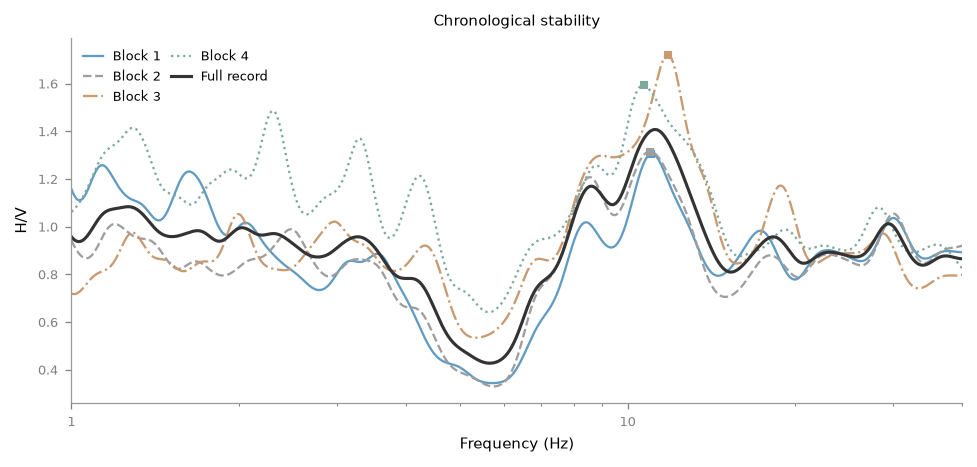

In [6]:
block_summary = pd.DataFrame(quality['time_blocks']).copy()
block_summary['start_min'] = block_summary['start_s'] / 60
block_summary['end_min'] = block_summary['end_s'] / 60
display(block_summary[[
    'block', 'start_min', 'end_min', 'n_windows',
    'f0_global_hz', 'A0_global', 'f0_tracked_hz', 'A0_tracked',
]].round(3))

time_blocks_figure = hp.plot_time_blocks(result, quality, style=FIGURE_STYLE)
display(time_blocks_figure)

## 5. Export


In [7]:
if SAVE_OUTPUTS:
    def input_hash(path):
        digest = hashlib.sha256()
        with path.open('rb') as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b''):
                digest.update(chunk)
        return digest.hexdigest()
    paths = [Path(path) for path in record.meta['file name(s)']]
    metadata = {
        'quality': quality, 'versions': versions,
        'accepted_signal_coverage': coverage,
        'peak_diagnostics': peak_diagnostics,
        'figure_style': asdict(FIGURE_STYLE), 'figure_formats': FIGURE_FORMATS,
        'figure_controls': FIGURE_CONTROLS,
        'input_sha256': {str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path): input_hash(path) for path in paths},
        'requested_interval_utc': {'starttime': STARTTIME, 'endtime': ENDTIME},
        'site_label': SITE_LABEL, 'site_label_source': 'user supplied', 'session_id': SESSION_ID,
        'interpretation': 'exploratory; no tested mean-curve peak reaches A0=2 and the selected profile fails SESAME clarity',
        'selection_basis': {
            'sensitivity_profiles': peak_diagnostics['profiles_tested'],
            'expanded_robustness_profiles': peak_diagnostics['expanded_robustness_profiles'],
            'defensible_candidate_rule': 'reliability 3/3; clarity >=5/6; full f0/4 to 4*f0 coverage; all four chronological blocks complete and tracked peaks within 10%',
            'selected_profile': 'best tested non-overlapping profile; overlap retained at 0% to avoid correlated-window inflation',
            'independent_validation': False,
        },
    }
    exported = hv.save_outputs(result, OUTPUT_DIR, OUTPUT_PREFIX, extra=metadata)
    pd.DataFrame(quality['criteria']).to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_criteria.csv', index=False)
    pd.DataFrame(quality['time_blocks']).to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_time_blocks.csv', index=False)
    peak_sweep.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_peak_sweep.csv', index=False)
    robustness_sweep.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_robustness_sweep.csv', index=False)
    figure_exports = {
        'analysis': hp.save_figure(analysis_figure, OUTPUT_DIR / f'{OUTPUT_PREFIX}_analysis', formats=FIGURE_FORMATS, style=FIGURE_STYLE),
        'time_blocks': hp.save_figure(time_blocks_figure, OUTPUT_DIR / f'{OUTPUT_PREFIX}_time_blocks', formats=FIGURE_FORMATS, style=FIGURE_STYLE),
    }
    print('Saved to', OUTPUT_DIR)
    display(exported)
else:
    print('Output saving disabled.')


Saved to /home/orincon/ciudad-perdida-hvsr/outputs/terraza_28


{'curve': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_30s_0pct_overlap_selected_fdr_curve.csv'),
 'windows': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_30s_0pct_overlap_selected_fdr_windows.csv'),
 'summary': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_30s_0pct_overlap_selected_fdr_summary.json'),
 'selection': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/terraza_28/terraza_28_CBUCF_titanSMA_1614_20230519_213500_02_30s_0pct_overlap_selected_fdr_selection.csv')}